In [1]:
import sys
import os

# Add the directory containing spectral_velocity_predictor.py to sys.path
module_dir = os.path.abspath("moving_mnist_fp")
if module_dir not in sys.path:
    sys.path.append(module_dir)

from spectral_velocity_predictor_models import PhaseCorrelation
# from moving_mnist_dataset import MovingMNISTDataset
from spectral_velocity_predictor_models import VelocityExtractor
from spectral_velocity_predictor_models import TorchLKVelocityExtractor

In [2]:
import torch
from torchvision.transforms import ToTensor
from torchvision.datasets import MNIST
import numpy as np
from torch.utils.data import Dataset
import torch.nn.functional as F

/mmfs1/cm/shared/apps_local/python/3.11/envs/torch2.2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
class MovingMNISTDatasetVel(Dataset):
    """
    PyTorch Dataset for generating sequences of moving MNIST digits with wrap-around boundary conditions.

    Args:
        root (str): path to download/load the MNIST data.
        train (bool): if True, load training split; otherwise, test split.
        seq_len (int): number of frames in each sequence.
        image_size (int): height and width of the square output frames.
        velocity_range_x (tuple of int): (min_vx, max_vx) inclusive range for horizontal velocity.
        velocity_range_y (tuple of int): (min_vy, max_vy) inclusive range for vertical velocity.
        num_digits (int): number of MNIST digits to overlay in each sequence.
        transform (callable, optional): transform applied to the full sequence tensor.
        download (bool): whether to download MNIST if not present.
        random (bool): if True, use random selection; if False, use deterministic random selection.
        seed (int): random seed for deterministic selection when random=False.
        return_velocity (bool): if True, also return per-digit velocities as tensor (num_digits, 2).
        avoid_duplicate_velocity_vectors (bool): if True, disallow exact duplicate (vx, vy) pairs across digits.
    """
    def __init__(
        self,
        root,
        train=True,
        seq_len=20,
        image_size=28,
        velocity_range_x=(-3, 3),
        velocity_range_y=(-3, 3),
        num_digits=2,
        transform=None,
        download=True,
        random=True,
        seed=42,
        return_velocity=True,
        avoid_duplicate_velocity_vectors=False,
    ):
        super().__init__()
        self.mnist = MNIST(root=root, train=train, download=download)
        self.seq_len = seq_len
        self.image_size = image_size
        self.vx_min, self.vx_max = velocity_range_x
        self.vy_min, self.vy_max = velocity_range_y
        self.num_digits = num_digits
        self.transform = transform
        self.to_tensor = ToTensor()
        self.random = random
        self.rng = np.random.RandomState(seed)
        self.return_velocity = return_velocity
        self.avoid_duplicate_velocity_vectors = avoid_duplicate_velocity_vectors

        if self.avoid_duplicate_velocity_vectors:
            n_vx = self.vx_max - self.vx_min + 1
            n_vy = self.vy_max - self.vy_min + 1
            max_unique_pairs = n_vx * n_vy
            if self.num_digits > max_unique_pairs:
                raise ValueError(
                    f"num_digits={self.num_digits} exceeds number of unique (vx,vy) pairs={max_unique_pairs} "
                    f"for ranges vx={velocity_range_x}, vy={velocity_range_y}."
                )

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, index):
        imgs = []
        labels = []
        for _ in range(self.num_digits):
            if self.random:
                idx = np.random.randint(0, len(self.mnist))
            else:
                idx = self.rng.randint(0, len(self.mnist))
            img_pil, lbl = self.mnist[idx]
            img = self.to_tensor(img_pil)  # shape: (1, 28, 28)
            imgs.append(img)
            labels.append(lbl)

        velocities_x = []
        velocities_y = []
        positions_x = []
        positions_y = []
        velocity_pairs = set()

        seq = torch.zeros(
            self.seq_len, 1, self.image_size, self.image_size, dtype=imgs[0].dtype
        )

        for _ in range(self.num_digits):
            if self.avoid_duplicate_velocity_vectors:
                while True:
                    if self.random:
                        vx = np.random.randint(self.vx_min, self.vx_max + 1)
                        vy = np.random.randint(self.vy_min, self.vy_max + 1)
                    else:
                        vx = self.rng.randint(self.vx_min, self.vx_max + 1)
                        vy = self.rng.randint(self.vy_min, self.vy_max + 1)

                    vel_pair = (int(vx), int(vy))
                    if vel_pair not in velocity_pairs:
                        velocity_pairs.add(vel_pair)
                        break
            else:
                if self.random:
                    vx = np.random.randint(self.vx_min, self.vx_max + 1)
                    vy = np.random.randint(self.vy_min, self.vy_max + 1)
                else:
                    vx = self.rng.randint(self.vx_min, self.vx_max + 1)
                    vy = self.rng.randint(self.vy_min, self.vy_max + 1)

            velocities_x.append(vx)
            velocities_y.append(vy)

            if self.random:
                x0 = np.random.randint(0, self.image_size)
                y0 = np.random.randint(0, self.image_size)
            else:
                x0 = self.rng.randint(0, self.image_size)
                y0 = self.rng.randint(0, self.image_size)
            positions_x.append(x0)
            positions_y.append(y0)

        for t in range(self.seq_len):
            frame = torch.zeros(1, self.image_size, self.image_size)

            for i, img in enumerate(imgs):
                pad_size = (self.image_size - img.shape[1]) // 2
                padded_img = F.pad(img, (pad_size, pad_size, pad_size, pad_size), "constant", 0)

                if padded_img.shape[1] < self.image_size:
                    padded_img = F.pad(
                        padded_img,
                        (0, self.image_size - padded_img.shape[2], 0, self.image_size - padded_img.shape[1]),
                        "constant",
                        0,
                    )

                img = padded_img

                shift_x = positions_x[i] + velocities_x[i] * t
                shift_y = positions_y[i] + velocities_y[i] * t

                moved = torch.roll(
                    img,
                    shifts=(shift_y, shift_x),
                    dims=(1, 2),
                )
                frame += moved

            seq[t] = frame.clamp(0.0, 1.0)

        if self.transform:
            seq = self.transform(seq)

        label_out = labels[0] if self.num_digits == 1 else torch.tensor(labels, dtype=torch.long)

        if self.return_velocity:
            velocity_out = torch.tensor(
                np.stack([velocities_x, velocities_y], axis=1), dtype=torch.float32
            )
            return seq, label_out, velocity_out

        return seq, label_out

In [4]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import torch.nn.functional as F

# Parameters
batch_size = 2
seq_len = 10
image_size = 28
num_digits = 2
n_modes = 2
# Create dataset
dataset = MovingMNISTDatasetVel(
    root="./data",
    seq_len=seq_len,
    image_size=image_size,
    num_digits=num_digits,
    velocity_range_x=(-3, 3),
    velocity_range_y=(-3, 3),
    random=True,
    avoid_duplicate_velocity_vectors = False,
)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


# Pick one batch
seq_batch, labels_batch, true_vel_batch = next(iter(dataloader))  # seq_batch: (B,T,1,H,W)
B, T, C, H, W = seq_batch.shape

# seq_batch: (B, T, C, H, W)
phase_corr = PhaseCorrelation(n_modes=n_modes, periodic_bc=True, subpixel=False)

velocities_est = phase_corr(seq_batch)  # returns (B, n_modes, 2)

# Print results
for b in range(B):
    print(f"\nSample {b}:")
    print("True velocities:")
    print(true_vel_batch[b])
    print("Estimated velocities (averaged over sequence):")
    print(velocities_est[b])


Sample 0:
True velocities:
tensor([[1., 2.],
        [0., 3.]])
Estimated velocities (averaged over sequence):
tensor([[[ 1.,  2.],
         [-0.,  3.]],

        [[ 1., -2.],
         [-2.,  3.]]])

Sample 1:
True velocities:
tensor([[ 1., -2.],
        [-2.,  3.]])
Estimated velocities (averaged over sequence):
tensor([[3.7056, 3.5019],
        [4.5422, 2.9100]])


In [5]:
import torch
import itertools

def batch_velocity_accuracy_subset(pred, true):
    """
    Computes best-match L2 error for a batch, even if n_modes > num_digits.
    For each sample:
        - Find the best subset of size num_digits from predictions
        - Find the permutation of this subset that minimizes L2 error to true velocities

    Args:
        pred: (B, n_modes, 2) predicted velocities
        true: (B, num_digits, 2) ground truth velocities

    Returns:
        mean_error: mean best-match L2 error over batch
        errors: list of best-match L2 errors per sample
        best_assignments: list of (subset_indices, permutation) per sample
    """
    B, n_modes, _ = pred.shape
    _, num_digits, _ = true.shape

    errors = []
    best_assignments = []

    for b in range(B):
        min_error = float('inf')
        best_subset = None
        best_perm = None

        # All subsets of n_modes predictions of size num_digits
        for subset_indices in itertools.combinations(range(n_modes), num_digits):
            subset_pred = pred[b, list(subset_indices)]  # (num_digits, 2)

            # All permutations of this subset
            for perm in itertools.permutations(range(num_digits)):
                perm = list(perm)
                subset_perm = subset_pred[perm]
                error = torch.norm(subset_perm - true[b], dim=1).sum().item()
                if error < min_error:
                    min_error = error
                    best_subset = subset_indices
                    best_perm = perm

        errors.append(min_error)
        best_assignments.append((best_subset, best_perm))

    mean_error = sum(errors) / B
    return mean_error, errors, best_assignments

In [26]:

# Parameters
batch_size = 10000
seq_len = 10
image_size = 32
num_digits = 2
n_modes = 5
# Create dataset
dataset = MovingMNISTDatasetVel(
    root="./data",
    seq_len=seq_len,
    image_size=image_size,
    num_digits=num_digits,
    velocity_range_x=(-3, 3),
    velocity_range_y=(-3, 3),
    random=True,
    avoid_duplicate_velocity_vectors = True
)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


# Pick one batch
seq_batch, labels_batch, true_vel_batch = next(iter(dataloader))  # seq_batch: (B,T,1,H,W)
B, T, C, H, W = seq_batch.shape

# seq_batch: (B, T, C, H, W)
phase_corr = PhaseCorrelation(n_modes=n_modes,  periodic_bc=True, subpixel=False)

import time 
start_time = time.time()
velocities_est, _ = phase_corr(seq_batch)  # returns (B, n_modes, 2)
finish_time = time.time()
print(f"Phase Correlation Predictor - Batch velocity estimation took {finish_time - start_time:.2f} seconds")


# pred: (B, n_modes, 2), true: (B, num_digits, 2)
mean_err, errors, assignments = batch_velocity_accuracy_subset(velocities_est, true_vel_batch)

print(f"Mean best-match L2 error over batch: {mean_err:.4f}")
# for b in range(len(errors)):
#     subset, perm = assignments[b]
#     print(f"\nSample {b}: error={errors[b]:.4f}")
#     print(f"Best subset of predictions: {subset}, permutation: {perm}")
#     # Show reordered predictions that match true velocities
#     reordered_pred = velocities_est[b, list(subset)][perm]
#     print("True velocities:      ", true_vel_batch[b])
#     print("Best-match prediction:", reordered_pred)

Phase Correlation Predictor - Batch velocity estimation took 0.34 seconds
Mean best-match L2 error over batch: 0.0002


In [25]:

# Parameters
batch_size = 10000
seq_len = 10
image_size = 32
num_digits = 2
n_modes = 5
# Create dataset
dataset = MovingMNISTDatasetVel(
    root="./data",
    seq_len=seq_len,
    image_size=image_size,
    num_digits=num_digits,
    velocity_range_x=(-3, 3),
    velocity_range_y=(-3, 3),
    random=True,
    avoid_duplicate_velocity_vectors = True
)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


# Pick one batch
seq_batch, labels_batch, true_vel_batch = next(iter(dataloader))  # seq_batch: (B,T,1,H,W)
B, T, C, H, W = seq_batch.shape

OF_vel_predictor = VelocityExtractor(method="lk", periodic_bc=True, n_modes=n_modes)
import time
start_time = time.time()
velocities_est_of, _ = OF_vel_predictor(seq_batch)  # (B, n_modes, 2)
finish_time = time.time()
print(f"Optical Flow Predictor - Batch velocity estimation took {finish_time - start_time:.2f} seconds")


mean_err_of, errors_of, assignments_of = batch_velocity_accuracy_subset(velocities_est_of, true_vel_batch)
print(f"\nOptical Flow Predictor - Mean best-match L2 error over batch: {mean_err_of:.4f}")
for b in range(len(errors_of)):
    subset, perm = assignments_of[b]
    print(f"\nSample {b}: error={errors_of[b]:.4f}")
    print(f"Best subset of predictions: {subset}, permutation: {perm}")
    # Show reordered predictions that match true velocities
    reordered_pred = velocities_est_of[b, list(subset)][perm]
    print("True velocities:      ", true_vel_batch[b])
    print("Best-match prediction:", reordered_pred)

Optical Flow Predictor - Batch velocity estimation took 12.79 seconds

Optical Flow Predictor - Mean best-match L2 error over batch: 0.7864

Sample 0: error=4.9363
Best subset of predictions: (0, 2), permutation: [1, 0]
True velocities:       tensor([[ 1., -3.],
        [ 0.,  2.]])
Best-match prediction: tensor([[ 0.0790,  1.7764],
        [-0.0645,  1.9681]], dtype=torch.float64)

Sample 1: error=0.5359
Best subset of predictions: (0, 1), permutation: [0, 1]
True velocities:       tensor([[-3., -3.],
        [ 2., -3.]])
Best-match prediction: tensor([[-2.8794, -3.2542],
        [ 1.9886, -3.2542]], dtype=torch.float64)

Sample 2: error=0.2920
Best subset of predictions: (1, 4), permutation: [1, 0]
True velocities:       tensor([[ 2., -3.],
        [ 2., -1.]])
Best-match prediction: tensor([[ 2.0663, -2.8333],
        [ 2.0663, -0.9090]], dtype=torch.float64)

Sample 3: error=0.3237
Best subset of predictions: (0, 2), permutation: [1, 0]
True velocities:       tensor([[ 3., -3.],
  

In [2]:
import torch
from torchvision.transforms import ToTensor
from torchvision.datasets import MNIST
import numpy as np
from torch.utils.data import Dataset
import torch.nn.functional as F

class MovingMNISTDataset(Dataset):
    """
    PyTorch Dataset for generating sequences of moving MNIST digits with wrap-around boundary conditions.

    Args:
        root (str): path to download/load the MNIST data.
        train (bool): if True, load training split; otherwise, test split.
        seq_len (int): number of frames in each sequence.
        image_size (int): height and width of the square output frames.
        velocity_range_x (tuple of int): (min_vx, max_vx) inclusive range for horizontal velocity.
        velocity_range_y (tuple of int): (min_vy, max_vy) inclusive range for vertical velocity.
        num_digits (int): number of MNIST digits to overlay in each sequence.
        transform (callable, optional): transform applied to the full sequence tensor.
        download (bool): whether to download MNIST if not present.
        random (bool): if True, use random selection; if False, use deterministic random selection.
        seed (int): random seed for deterministic selection when random=False.
        return_velocity (bool): if True, also return per-digit velocities as tensor (num_digits, 2).
        avoid_duplicate_velocity_vectors (bool): if True, disallow exact duplicate (vx, vy) pairs across digits.
    """
    def __init__(
        self,
        root,
        train=True,
        seq_len=20,
        image_size=28,
        velocity_range_x=(-3, 3),
        velocity_range_y=(-3, 3),
        num_digits=2,
        transform=None,
        download=True,
        random=True,
        seed=42,
        return_velocity=True,
        avoid_duplicate_velocity_vectors=False,
    ):
        super().__init__()
        self.mnist = MNIST(root=root, train=train, download=download)
        self.seq_len = seq_len
        self.image_size = image_size
        self.vx_min, self.vx_max = velocity_range_x
        self.vy_min, self.vy_max = velocity_range_y
        self.num_digits = num_digits
        self.transform = transform
        self.to_tensor = ToTensor()
        self.random = random
        self.rng = np.random.RandomState(seed)
        self.return_velocity = return_velocity
        self.avoid_duplicate_velocity_vectors = avoid_duplicate_velocity_vectors

        if self.avoid_duplicate_velocity_vectors:
            n_vx = self.vx_max - self.vx_min + 1
            n_vy = self.vy_max - self.vy_min + 1
            max_unique_pairs = n_vx * n_vy
            if self.num_digits > max_unique_pairs:
                raise ValueError(
                    f"num_digits={self.num_digits} exceeds number of unique (vx,vy) pairs={max_unique_pairs} "
                    f"for ranges vx={velocity_range_x}, vy={velocity_range_y}."
                )

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, index):
        imgs = []
        labels = []
        for _ in range(self.num_digits):
            if self.random:
                idx = np.random.randint(0, len(self.mnist))
            else:
                idx = self.rng.randint(0, len(self.mnist))
            img_pil, lbl = self.mnist[idx]
            img = self.to_tensor(img_pil)  # shape: (1, 28, 28)
            imgs.append(img)
            labels.append(lbl)

        velocities_x = []
        velocities_y = []
        positions_x = []
        positions_y = []
        velocity_pairs = set()

        seq = torch.zeros(
            self.seq_len, 1, self.image_size, self.image_size, dtype=imgs[0].dtype
        )

        for _ in range(self.num_digits):
            if self.avoid_duplicate_velocity_vectors:
                while True:
                    if self.random:
                        vx = np.random.randint(self.vx_min, self.vx_max + 1)
                        vy = np.random.randint(self.vy_min, self.vy_max + 1)
                    else:
                        vx = self.rng.randint(self.vx_min, self.vx_max + 1)
                        vy = self.rng.randint(self.vy_min, self.vy_max + 1)

                    vel_pair = (int(vx), int(vy))
                    if vel_pair not in velocity_pairs:
                        velocity_pairs.add(vel_pair)
                        break
            else:
                if self.random:
                    vx = np.random.randint(self.vx_min, self.vx_max + 1)
                    vy = np.random.randint(self.vy_min, self.vy_max + 1)
                else:
                    vx = self.rng.randint(self.vx_min, self.vx_max + 1)
                    vy = self.rng.randint(self.vy_min, self.vy_max + 1)

            velocities_x.append(vx)
            velocities_y.append(vy)

            if self.random:
                x0 = np.random.randint(0, self.image_size)
                y0 = np.random.randint(0, self.image_size)
            else:
                x0 = self.rng.randint(0, self.image_size)
                y0 = self.rng.randint(0, self.image_size)
            positions_x.append(x0)
            positions_y.append(y0)

        for t in range(self.seq_len):
            frame = torch.zeros(1, self.image_size, self.image_size)

            for i, img in enumerate(imgs):
                pad_size = (self.image_size - img.shape[1]) // 2
                padded_img = F.pad(img, (pad_size, pad_size, pad_size, pad_size), "constant", 0)

                if padded_img.shape[1] < self.image_size:
                    padded_img = F.pad(
                        padded_img,
                        (0, self.image_size - padded_img.shape[2], 0, self.image_size - padded_img.shape[1]),
                        "constant",
                        0,
                    )

                img = padded_img

                shift_x = positions_x[i] + velocities_x[i] * t
                shift_y = positions_y[i] + velocities_y[i] * t

                moved = torch.roll(
                    img,
                    shifts=(shift_y, shift_x),
                    dims=(1, 2),
                )
                frame += moved

            seq[t] = frame.clamp(0.0, 1.0)

        if self.transform:
            seq = self.transform(seq)

        label_out = labels[0] if self.num_digits == 1 else torch.tensor(labels, dtype=torch.long)

        if self.return_velocity:
            velocity_out = torch.tensor(
                np.stack([velocities_x, velocities_y], axis=1), dtype=torch.float32
            )
            return seq, label_out, velocity_out

        return seq, label_out

In [1]:
import torch
from torchvision.models.optical_flow import raft_large
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

model = raft_large(weights="DEFAULT").to(device)
model.eval()

/mmfs1/cm/shared/apps_local/python/3.11/envs/torch2.2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


RAFT(
  (feature_encoder): FeatureEncoder(
    (convnormrelu): Conv2dNormActivation(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
      (1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): ReLU(inplace=True)
    )
    (layer1): Sequential(
      (0): ResidualBlock(
        (convnormrelu1): Conv2dNormActivation(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
          (2): ReLU(inplace=True)
        )
        (convnormrelu2): Conv2dNormActivation(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
          (2): ReLU(inplace=True)
        )
        (downsample): Identity()
        (relu): ReLU(inplace=True)
      )
      (1): ResidualBlock(
        (

In [31]:
train_dataset_Mnist = MovingMNISTDataset(
    root='./data',
    train=True,
    seq_len=10,
    image_size=128,
    velocity_range_x=(-5, 5),
    velocity_range_y=(-5, 5),
    num_digits=2,
    return_velocity=True,
)

In [32]:
seq, labels, vels = train_dataset_Mnist[0]

In [33]:
seq_rgb = seq.repeat(1, 3, 1, 1)

In [55]:
seq_rgb.shape, seq.shape

(torch.Size([10, 3, 128, 128]), torch.Size([10, 1, 128, 128]))

In [35]:
flows = []

with torch.no_grad():
    for t in range(seq_rgb.shape[0] - 1):
        frame1 = seq_rgb[t].unsqueeze(0).to(device)  # (1, 3, H, W)
        frame2 = seq_rgb[t+1].unsqueeze(0).to(device)

        flow_predictions = model(frame1, frame2)
        flow = flow_predictions[-1]  # final refined flow

        flows.append(flow.cpu())

flows = torch.cat(flows, dim=0)

In [36]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import imageio

In [37]:
def show_frame(seq, t=0):
    frame = seq[t, 0].cpu().numpy()

    plt.figure()
    plt.imshow(frame)
    plt.title(f"Frame {t}")
    plt.axis("off")
    plt.show()

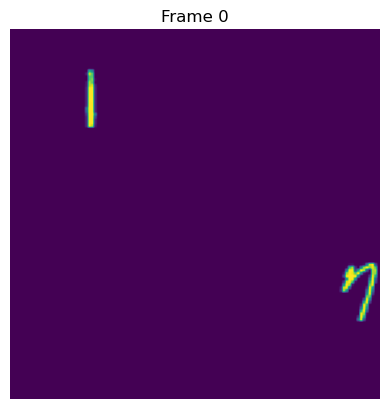

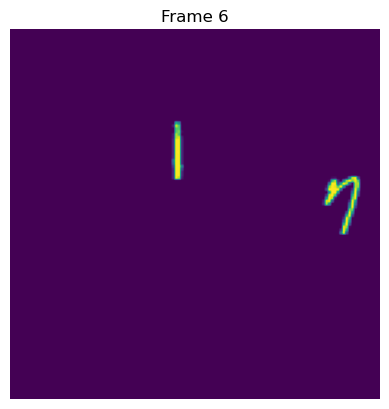

(None, None)

In [56]:
show_frame(seq, t=0), show_frame(seq, t=6)

In [39]:
def show_flow(seq, flows, t=0, step=8):
    """
    step: downsample arrows for clarity
    """
    img = seq[t, 0].cpu().numpy()
    flow = flows[t].cpu().numpy()  # (2, H, W)

    u = flow[0]
    v = flow[1]

    H, W = img.shape
    y, x = np.mgrid[0:H, 0:W]

    plt.figure()
    plt.imshow(img)
    plt.quiver(
        x[::step, ::step],
        y[::step, ::step],
        u[::step, ::step],
        v[::step, ::step]
    )
    plt.title(f"Flow at t={t}")
    plt.axis("off")
    plt.show()

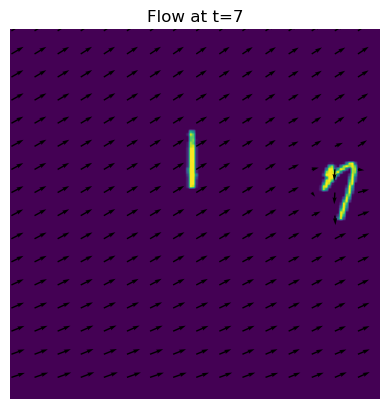

In [61]:
show_flow(seq, flows, t=7)

In [41]:
def plot_mean_velocity(flows):
    mean_velocities = []

    for t in range(flows.shape[0]):
        flow = flows[t]
        mean = flow.mean(dim=[1,2])  # (2,)
        mean_velocities.append(mean.cpu().numpy())

    mean_velocities = np.array(mean_velocities)

    plt.figure()
    plt.plot(mean_velocities[:, 0])
    plt.title("Mean Horizontal Velocity Over Time")
    plt.xlabel("Time")
    plt.ylabel("vx")
    plt.show()

    plt.figure()
    plt.plot(mean_velocities[:, 1])
    plt.title("Mean Vertical Velocity Over Time")
    plt.xlabel("Time")
    plt.ylabel("vy")
    plt.show()

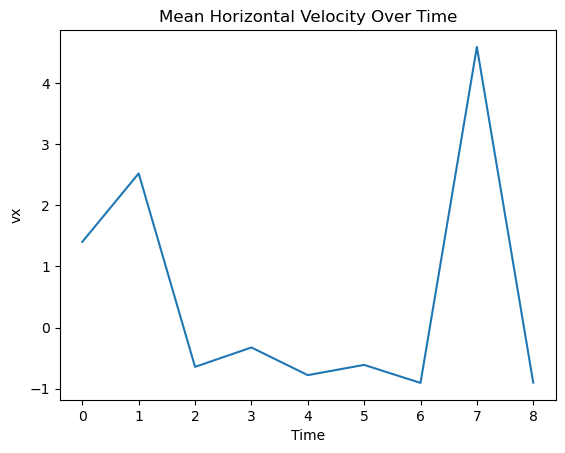

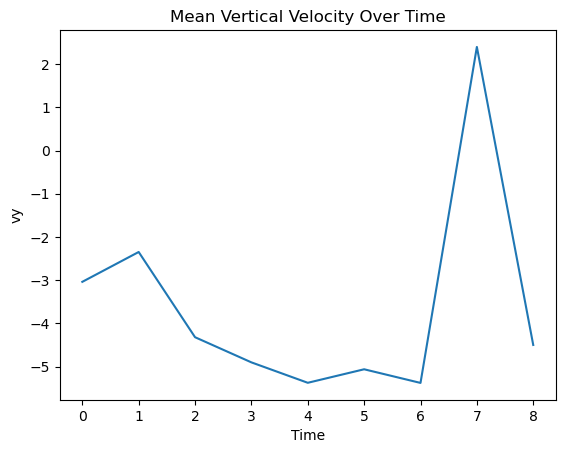

(None,
 tensor([[-1., -5.],
         [ 5.,  3.]]))

In [48]:
plot_mean_velocity(flows), vels

In [43]:
def save_sequence_gif(seq, filename="sequence.gif", fps=5):
    frames = []

    for t in range(seq.shape[0]):
        frame = seq[t, 0].cpu().numpy()
        frame_uint8 = (frame * 255).astype(np.uint8)
        frames.append(frame_uint8)

    imageio.mimsave(filename, frames, fps=fps)

In [44]:
save_sequence_gif(seq, filename="moving_mnist_sequence.gif", fps=5)

In [45]:
def save_flow_magnitude_gif(flows, filename="flow_magnitude.gif", fps=5):
    frames = []

    for t in range(flows.shape[0]):
        flow = flows[t].cpu().numpy()
        magnitude = np.sqrt(flow[0]**2 + flow[1]**2)

        # Normalize for visualization
        magnitude = magnitude / (magnitude.max() + 1e-6)
        magnitude_uint8 = (magnitude * 255).astype(np.uint8)

        frames.append(magnitude_uint8)

    imageio.mimsave(filename, frames, fps=fps)

In [62]:
save_flow_magnitude_gif(flows, filename="flow_magnitude.gif", fps=5)

In [46]:
def show_flow_magnitude(flows, t=0):
    flow = flows[t].cpu().numpy()
    magnitude = np.sqrt(flow[0]**2 + flow[1]**2)

    plt.figure()
    plt.imshow(magnitude)
    plt.title(f"Flow Magnitude at t={t}")
    plt.axis("off")
    plt.show()

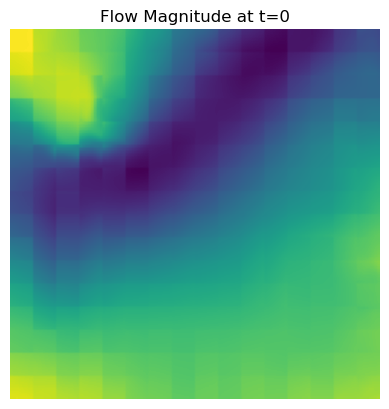

In [47]:
show_flow_magnitude(flows, t=0)